# **Training model**

In [1]:
import os
import sys 
from pathlib import Path 

import pandas as pd

BASE_DIR = os.getcwd()
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)
    
from sklearn.model_selection import train_test_split
from src.data_loader import DataCleaner
from src.optuna_optimize import optimize_model_fast
from src.models import get_models
from src.training import create_pipeline
from src.evaluate import get_metrics

%load_ext autoreload
%autoreload 2

d:\03 Data science\00 AIO2025\01 Projects\Case12.2_Credit_Risk\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset Home Credit
cleaner = DataCleaner()
df_train, df_test = cleaner.run_cleaner()

[data]  found 9 raw file(s)
  ← application_test.csv  shape=(48744, 121)
  ← application_train.csv  shape=(307511, 122)
  ← bureau.csv  shape=(1716428, 17)
  ← bureau_balance.csv  shape=(27299925, 3)
  ← credit_card_balance.csv  shape=(3840312, 23)
  ← installments_payments.csv  shape=(13605401, 8)
  ← POS_CASH_balance.csv  shape=(10001358, 8)
  ← previous_application.csv  shape=(1670214, 37)
  ← sample_submission.csv  shape=(48744, 2)
[data]  train shape: (307511, 119)
[data]  test  shape: (48744, 118)
[data]  saved successfully!


In [3]:
df_train.head()

,DEFAULT,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Train/ Val/ Test
X_train = df_train.drop(columns=["DEFAULT"])
y_train = df_train["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [5]:
X_train.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
170657,Cash loans,F,N,Y,0,74250.0,112500.0,6282.0,112500.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,2.0
251121,Revolving loans,F,Y,Y,2,225000.0,810000.0,40500.0,810000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
96789,Cash loans,M,Y,N,0,225000.0,1546020.0,42642.0,1350000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
14042,Cash loans,M,Y,Y,1,202500.0,444420.0,30195.0,337500.0,Family,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
32597,Cash loans,F,N,Y,2,126000.0,1216201.5,35689.5,1062000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
classifiers = get_models()
rf_classifier = classifiers['Random Forest']

In [7]:
pipeline = create_pipeline(
    X_train,
    y_train,
    classifier = rf_classifier,
    cat_cols = "infer",
    onehot = True,
    onehotdrop = False,
    normalize = True,
    do_EBE = True,
)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fill', ...), ('le', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [8]:
from sklearn.ensemble import RandomForestClassifier

_, model = optimize_model_fast(
    RandomForestClassifier,
    "suggest",
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials = 5,
    seed_number = 42    
)

Best trial: 0. Best value: 0.737031: 100%|██████████| 5/5 [08:09<00:00, 97.91s/it] 


In [9]:
from src.training import ks_threshold

y_prob = model.predict_proba(X_test)[:, 1]
thresh = ks_threshold(y_test, y_prob)
print(thresh)

metrics = get_metrics(
    {"Baseline": pipeline, "Optimized": [model, thresh]},
    X_test,
    y_test,
)
metrics

0.4321517168568032


,model,AUC,Brier Score,Balanced Accuracy,Accuracy,Precision,Recall,F1
0,Baseline,0.708258,0.070051,0.501278,0.919679,0.764706,0.002627,0.005236
1,Optimized,0.743632,0.177248,0.681781,0.653659,0.151075,0.715296,0.249463


In [10]:
y_prob = model.predict_proba(X_test)[:, 1]
ks_thresh = ks_threshold(y_val, model.predict_proba(X_val)[:, 1])

print("KS threshold:", ks_thresh)
print("Max prob on test:", y_prob.max())
print("% vượt threshold:", (y_prob >= ks_thresh).mean())

KS threshold: 0.40044928093051824
Max prob on test: 0.8601015640873341
% vượt threshold: 0.4422711087264036


Best params: {'n_estimators': 97, 'max_depth': 12, 'criterion': 'gini', 'min_samples_split': 41, 'min_samples_leaf': 40, 'max_features': 0.15227525095137953, 'class_weight': 'balanced'}


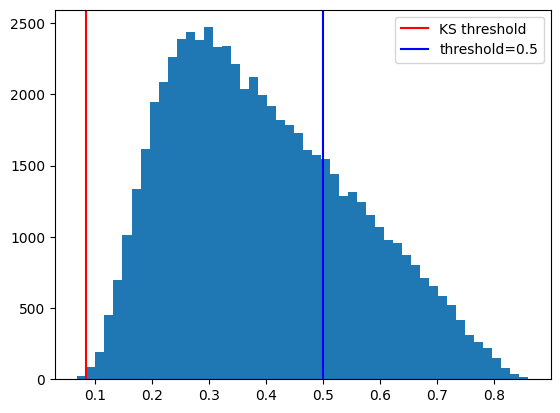

X_train shape: (184506, 118)
X_val shape: (61502, 118)
X_test shape: (61503, 118)
y_train default rate: 0.08053396637507723
y_val default rate: 0.08157458294039219
y_test default rate: 0.08046761946571712


In [11]:
# 1. Xem best params Optuna tìm được
print("Best params:", _)  # _ là best_params trả về từ optimize_model_fast

# 2. Xem phân phối prob
import matplotlib.pyplot as plt
y_prob = model.predict_proba(X_test)[:, 1]
plt.hist(y_prob, bins=50)
plt.axvline(0.084, color='red', label='KS threshold')
plt.axvline(0.5,   color='blue', label='threshold=0.5')
plt.legend()
plt.show()

# 3. So sánh kích thước data
print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)
print("y_train default rate:", y_train.mean())
print("y_val default rate:",   y_val.mean())
print("y_test default rate:",  y_test.mean())

In [14]:
import joblib

models_path = os.path.join(BASE_DIR, "outputs","models" )
best_params = _
joblib.dump(model, os.path.join(models_path, "randomforest_params_optimized.joblib"))
print("Best params:", best_params)

Best params: {'n_estimators': 97, 'max_depth': 12, 'criterion': 'gini', 'min_samples_split': 41, 'min_samples_leaf': 40, 'max_features': 0.15227525095137953, 'class_weight': 'balanced'}
